In [22]:
import pandas as pd

df = pd.read_csv("data/reduced_world_real_estate_data.csv")

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144961 entries, 0 to 144960
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Country              144961 non-null  object 
 1   Property_Type        144961 non-null  object 
 2   Height               144961 non-null  float64
 3   Price_and_Modernity  144961 non-null  float64
 4   Building_Age         144961 non-null  float64
 5   Interior_Amenities   144961 non-null  float64
 6   Total_Area           144961 non-null  float64
dtypes: float64(5), object(2)
memory usage: 7.7+ MB


In [24]:
df.describe(include='all')

,Country,Property_Type,Height,Price_and_Modernity,Building_Age,Interior_Amenities,Total_Area
count,144961,144961,1.449610e+05,1.449610e+05,1.449610e+05,1.449610e+05,1.449610e+05
unique,27,4,NaN,NaN,NaN,NaN,NaN
top,Turkey,apartment,NaN,NaN,NaN,NaN,NaN
freq,25681,97212,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.333239e-17,5.019252e-17,-1.097961e-17,1.646942e-17,-3.039000e-18
std,NaN,NaN,1.574210e+00,1.449331e+00,1.144371e+00,1.057459e+00,9.964225e-01
min,NaN,NaN,-1.458574e+01,-9.073894e+00,-9.380603e+01,-8.538361e+01,-3.502881e+01
25%,NaN,NaN,-1.037422e+00,-3.849956e-01,-3.183065e-01,-4.615435e-01,-6.283187e-02
50%,NaN,NaN,1.187990e-01,9.475008e-02,2.022144e-01,-1.490901e-01,4.880248e-02
75%,NaN,NaN,9.137426e-01,5.651392e-01,6.070591e-01,2.878593e-01,1.684099e-01


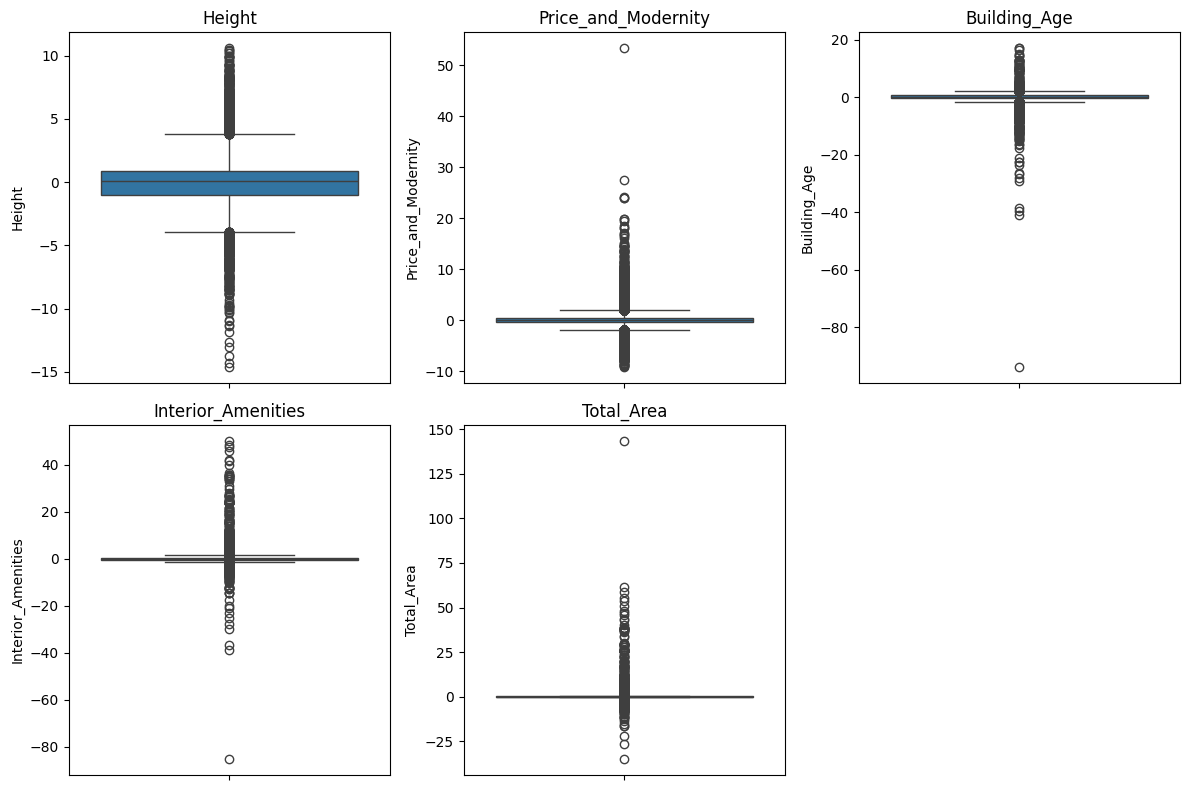

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['Height', 'Price_and_Modernity', 'Building_Age', 'Interior_Amenities', 'Total_Area']

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [26]:
from scipy import stats
import numpy as np

zscore_mask = np.zeros(len(df), dtype=bool)
zscore_info = {}

for col in num_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    mask = z_scores > 3  
    zscore_info[col] = mask.sum()
    zscore_mask |= mask

df['is_outlier_zscore'] = zscore_mask
print("Z-Score Outliers (|z| > 3):")
print(f"Total: {df['is_outlier_zscore'].sum()} ({df['is_outlier_zscore'].mean()*100:.2f}%)")
print("\nOutliers per PC:")
for col, count in zscore_info.items():
    print(f"  {col}: {count}")

Z-Score Outliers (|z| > 3):
Total: 7243 (5.00%)

Outliers per PC:
  Height: 1232
  Price_and_Modernity: 5212
  Building_Age: 2562
  Interior_Amenities: 954
  Total_Area: 548


In [27]:
outlier_mask = np.zeros(len(df), dtype=bool)
outlier_info = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df[col] < lower) | (df[col] > upper)
    outlier_info[col] = mask.sum()  
    outlier_mask |= mask

df['is_outlier_iqr'] = outlier_mask
print("IQR Outliers (1.5 * IQR rule):")
print(f"Total: {df['is_outlier_iqr'].sum()} ({df['is_outlier_iqr'].mean()*100:.2f}%)")
print("\nOutliers per PC:")
for col, count in outlier_info.items():
    print(f"  {col}: {count}")

IQR Outliers (1.5 * IQR rule):
Total: 32950 (22.73%)

Outliers per PC:
  Height: 2603
  Price_and_Modernity: 14490
  Building_Age: 9796
  Interior_Amenities: 5663
  Total_Area: 19931


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144961 entries, 0 to 144960
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Country              144961 non-null  object 
 1   Property_Type        144961 non-null  object 
 2   Height               144961 non-null  float64
 3   Price_and_Modernity  144961 non-null  float64
 4   Building_Age         144961 non-null  float64
 5   Interior_Amenities   144961 non-null  float64
 6   Total_Area           144961 non-null  float64
 7   is_outlier_zscore    144961 non-null  bool   
 8   is_outlier_iqr       144961 non-null  bool   
dtypes: bool(2), float64(5), object(2)
memory usage: 8.0+ MB
